## Lagrange Applications in Economics - Talha Sadiq, Shiwam K.C, Sandro 



## 0 · Imports

In [8]:
import numpy as np
import sympy as sp
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
})

# 1. Lagrange Multipliers — Utility Maximisation

$$
\max_{x,y}\; x^{1/2}y^{1/2} \quad \text{subject to} \quad 2x + 4y = 100
$$

X* = 25.0
y* = 12.5


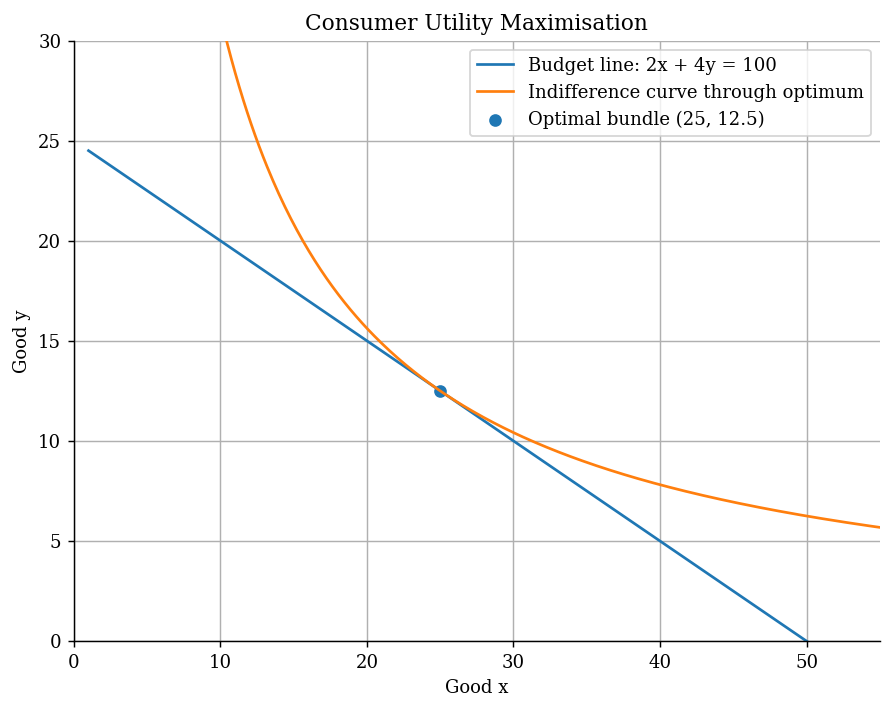

In [ ]:
# Parameters
px = 2
py = 4
I = 100

# Symbols
x, y = sp.symbols('x y', positive=True)

# Utility function
U = sp.sqrt(x) * sp.sqrt(y)

# Lagrangian first-order result:
eq1 = sp.Eq(y / x, px / py)

# Budget constraint
eq2 = sp.Eq(px * x + py * y, I)

# Solve for optimal bundle
sol = sp.solve((eq1, eq2), (x, y))
x_star = float(sol[x])
y_star = float(sol[y])

print(f"X* = {x_star}")
print(f"y* = {y_star}")

# Utility level at the optimum
U_star = float(sp.sqrt(x_star) * sp.sqrt(y_star))

# Plot range
x_vals = np.linspace(1, 55, 400)

# Budget constraint
y_budget = (I - px * x_vals) / py

# Indifference curve 
y_indiff = (U_star ** 2) / x_vals

# Plot
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_budget, label='Budget line: 2x + 4y = 100')
plt.plot(x_vals, y_indiff, label='Indifference curve through optimum')
plt.scatter(x_star, y_star, label=f'Optimal bundle ({x_star:.0f}, {y_star:.1f})')

plt.xlim(0, 55)
plt.ylim(0, 30)
plt.xlabel('Good x')
plt.ylabel('Good y')
plt.title('Consumer Utility Maximisation')
plt.legend()
plt.grid(True)
plt.show()

# Lagrange Multipliers — Cost Minimisation


$$\min_{K,\,L}\; rK + wL \quad \text{subject to} \quad F(K,L) = \bar{q}$$

using a **Cobb–Douglas** production function $F(K,L) = K^{\alpha} L^{\beta}$.




## 1 · Parameters

Edit the values in this single cell to re-run the entire analysis.

In [10]:
#  Production function: F(K, L) = K^alpha * L^beta 
ALPHA = 1/3      # capital elasticity
BETA  = 2/3      # labour  elasticity  (ALPHA + BETA = 1 → CRS)

#  Input prices 
R = 3.0          # rental rate of capital
W = 6.0          # wage rate of labour

#  Output target 
Q_BAR = 100.0    # units of output to produce

print(f"Parameters  →  α={ALPHA:.3f}  β={BETA:.3f}  r={R}  w={W}  q̄={Q_BAR}")

Parameters  →  α=0.333  β=0.667  r=3.0  w=6.0  q̄=100.0



## 2 · Symbolic Derivation (SymPy)

We build the Lagrangian
$$\mathcal{L}(K, L, \lambda) = rK + wL - \lambda\bigl(K^\alpha L^\beta - \bar{q}\bigr)$$
and solve the first-order conditions analytically.

In [11]:
#  Symbolic variables 
K, L, lam = sp.symbols('K L lambda', positive=True)
r, w, alpha, beta, q = sp.symbols('r w alpha beta q', positive=True)

#  Production function & cost 
F    = K**alpha * L**beta
cost = r*K + w*L

#  Lagrangian 
Lagrangian = cost - lam * (F - q)

print("Lagrangian:")
display(sp.Eq(sp.Symbol('L'), Lagrangian))

Lagrangian:


Eq(L, K*r + L*w - lambda*(K**alpha*L**beta - q))

In [31]:
#  First-order conditions 
foc_K   = sp.diff(Lagrangian, K)
foc_L   = sp.diff(Lagrangian, L)
foc_lam = sp.diff(Lagrangian, lam)   # → -(F - q) = 0

print("FOC w.r.t. K :"); display(sp.Eq(foc_K,   0))
print("FOC w.r.t. L :"); display(sp.Eq(foc_L,   0))
print("FOC w.r.t. λ :"); display(sp.Eq(foc_lam, 0))

FOC w.r.t. K :


Eq(r - K**alpha*L**beta*alpha*lambda/K, 0)

FOC w.r.t. L :


Eq(-K**alpha*L**beta*beta*lambda/L + w, 0)

FOC w.r.t. λ :


Eq(-K**alpha*L**beta + q, 0)

In [30]:
#  Solve the system 
solution = sp.solve([foc_K, foc_L, foc_lam], [K, L, lam], dict=True)[0]

K_star   = sp.simplify(solution[K])
L_star   = sp.simplify(solution[L])
lam_star = sp.simplify(solution[lam])

print("Optimal capital K*(r, w, q):"  ); display(K_star)
print("Optimal labour L*(r, w, q):"  ); display(L_star)
print("Shadow price λ*(r, w, q):"  ); display(lam_star)

Optimal capital K*(r, w, q):


q**(1/alpha)*(alpha*w/(beta*q**(1/alpha)*r))**(beta/(alpha + beta))

Optimal labour L*(r, w, q):


(beta*q**(1/alpha)*r/(alpha*w))**(alpha/(alpha + beta))

Shadow price λ*(r, w, q):


w*(beta*q**(1/alpha)*r/(alpha*w))**(alpha/(alpha + beta))/(beta*q)

In [14]:
#  Minimum cost function 
C_star = sp.simplify(r*K_star + w*L_star)
print("Minimum cost C*(r, w, q):")
display(C_star)

# Verify envelope theorem: dC*/dq = lambda*
dC_dq  = sp.simplify(sp.diff(C_star, q))
print("\nEnvelope theorem check  →  ∂C*/∂q =")
display(dC_dq)
print("λ* =")
display(lam_star)
print("Equal?", sp.simplify(dC_dq - lam_star) == 0)

Minimum cost C*(r, w, q):


q**(1/alpha)*r*w*(1/(alpha*w))**(alpha/(alpha + beta))*(1/(beta*q**(1/alpha)*r))**(beta/(alpha + beta))*(alpha + beta)


Envelope theorem check  →  ∂C*/∂q =


q**(-1 + 1/alpha)*r*w*(1/(alpha*w))**(alpha/(alpha + beta))*(1/(beta*q**(1/alpha)*r))**(beta/(alpha + beta))

λ* =


w*(beta*q**(1/alpha)*r/(alpha*w))**(alpha/(alpha + beta))/(beta*q)

Equal? True



## 3 · Numerical Solution (SciPy)

We now substitute the parameter values and solve numerically,
both via the **closed-form formulas** derived above and via
**SciPy's constrained minimiser** as a cross-check.

In [29]:
# Closed-form solution using the Lagrangian method
subs = {r: R, w: W, alpha: ALPHA, beta: BETA, q: Q_BAR}

K_opt      = float(K_star.subs(subs))
L_opt      = float(L_star.subs(subs))
lam_opt    = float(lam_star.subs(subs))
C_opt      = float(C_star.subs(subs))
output_chk = K_opt**ALPHA * L_opt**BETA

print("Results from the closed-form (Lagrange) solution:")
print(f"Capital (K*) = {K_opt:.4f}")
print(f"Labour  (L*) = {L_opt:.4f}")
print(f"Shadow price λ (marginal cost) = {lam_opt:.4f}")
print(f"Minimum cost = {C_opt:.4f}")
print(f"Output check: F(K*,L*) = {output_chk:.4f} (target output = {Q_BAR})")

Results from the closed-form (Lagrange) solution:
Capital (K*) = 100.0000
Labour  (L*) = 100.0000
Shadow price λ (marginal cost) = 9.0000
Minimum cost = 900.0000
Output check: F(K*,L*) = 100.0000 (target output = 100.0)


In [26]:
# Use SciPy to solve the cost minimisation problem numerically
def total_cost(x):
    K_n, L_n = x
    return R * K_n + W * L_n

def production_constraint(x):
    K_n, L_n = x
    return K_n**ALPHA * L_n**BETA - Q_BAR   # this should be equal to 0

constraint = {'type': 'eq', 'fun': production_constraint}
bounds     = [(1e-6, None), (1e-6, None)]    # both inputs must stay positive
x0         = [Q_BAR / 2, Q_BAR / 2]          # starting values for K and L

res = minimize(total_cost, x0, method='SLSQP',
               constraints=constraint, bounds=bounds,
               options={'ftol': 1e-12, 'maxiter': 1000})

K_scipy, L_scipy = res.x
C_scipy          = res.fun

print("Results from the SciPy optimisation:")
print(f"Capital (K*) = {K_scipy:.4f}")
print(f"Labour  (L*) = {L_scipy:.4f}")
print(f"Minimum cost = {C_scipy:.4f}")
print(f"Did the algorithm converge? {res.success} ({res.message})")

print("\nDifference compared with the closed-form solution:")
print(f"Difference in K  = {abs(K_opt - K_scipy):.2e}")
print(f"Difference in L  = {abs(L_opt - L_scipy):.2e}")
print(f"Difference in cost = {abs(C_opt - C_scipy):.2e}")

Results from the SciPy optimisation:
Capital (K*) = 99.9999
Labour  (L*) = 100.0001
Minimum cost = 900.0000
Did the algorithm converge? True (Optimization terminated successfully)

Difference compared with the closed-form solution:
Difference in K  = 1.18e-04
Difference in L  = 5.89e-05
Difference in cost = 3.13e-10



## 4 · Visualisation — Isoquant & Isocost Map

<>:30: SyntaxWarning: invalid escape sequence '\,'
<>:30: SyntaxWarning: invalid escape sequence '\,'
/var/folders/hp/n3f9b8ts7n52zgs425p3qtfm0000gn/T/ipykernel_15168/4216061120.py:30: SyntaxWarning: invalid escape sequence '\,'
  label=f'Optimum $(K^*,L^*)=({K_opt:.1f},\, {L_opt:.1f})$')


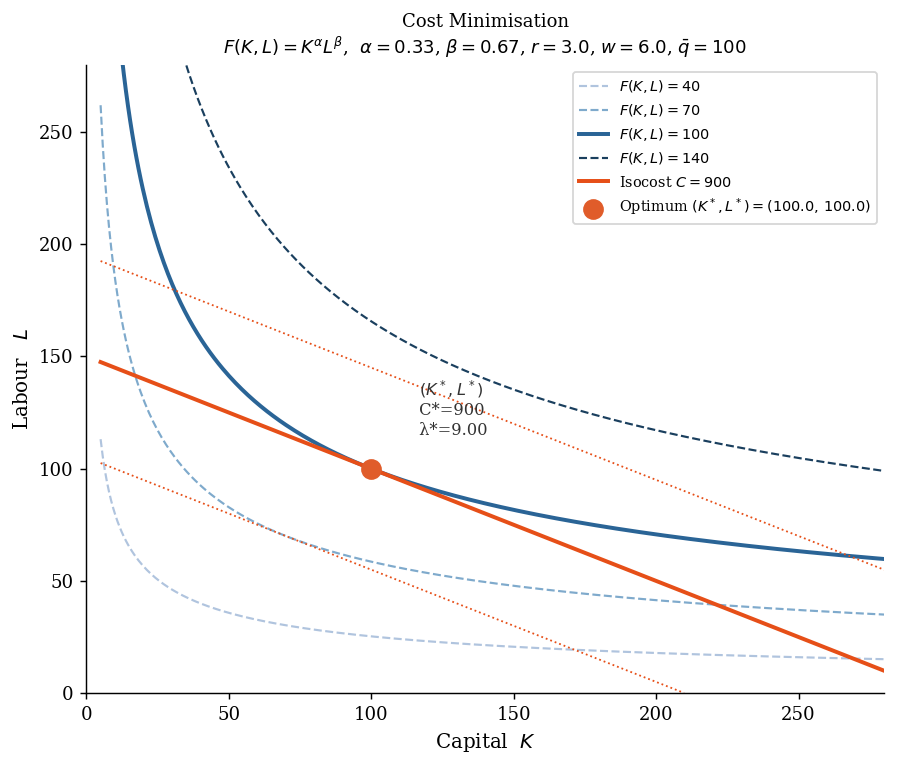

Figure saved as isoquant_isocost.png


In [24]:
K_grid = np.linspace(5, 300, 400)

fig, ax = plt.subplots(figsize=(7, 6))

#  Isoquants for several output levels 
q_levels = [Q_BAR * f for f in (0.4, 0.7, 1.0, 1.4)]
colours  = ['#b0c4de', '#7faacc', '#2a6496', '#1a3f5e']

for q_lvl, col in zip(q_levels, colours):
    # L = (q / K^alpha)^(1/beta)
    L_iq = (q_lvl / K_grid**ALPHA) ** (1 / BETA)
    lw   = 2.2 if q_lvl == Q_BAR else 1.2
    ls   = '-'  if q_lvl == Q_BAR else '--'
    ax.plot(K_grid, L_iq, color=col, lw=lw, ls=ls,
            label=f'$F(K,L)={q_lvl:.0f}$')

#  Isocost lines 
cost_levels = [C_opt * f for f in (0.7, 1.0, 1.3)]
for c_lvl in cost_levels:
    # L = (C - rK) / w
    L_ic = (c_lvl - R * K_grid) / W
    mask = L_ic > 0
    lw   = 2.2 if c_lvl == C_opt else 1.0
    ax.plot(K_grid[mask], L_ic[mask], color="#e64f18", lw=lw,
            ls=('-' if c_lvl == C_opt else ':'),
            label=(f'Isocost $C={c_lvl:.0f}$' if c_lvl == C_opt else None))

#  Optimum point 
ax.scatter(K_opt, L_opt, s=110, color='#e05c2a', zorder=5,
           label=f'Optimum $(K^*,L^*)=({K_opt:.1f},\, {L_opt:.1f})$')
ax.annotate(f' $(K^*,L^*)$\n C*={C_opt:.0f}\n λ*={lam_opt:.2f}',
            xy=(K_opt, L_opt), xytext=(K_opt + 15, L_opt + 15),
            fontsize=9, color='#333')

ax.set_xlim(0, 280); ax.set_ylim(0, 280)
ax.set_xlabel('Capital  $K$', fontsize=11)
ax.set_ylabel('Labour   $L$', fontsize=11)
ax.set_title(f'Cost Minimisation\n'
             f'$F(K,L)=K^{{\\alpha}}L^{{\\beta}}$,  '
             f'$\\alpha={ALPHA:.2f}$, $\\beta={BETA:.2f}$, '
             f'$r={R}$, $w={W}$, $\\bar{{q}}={Q_BAR:.0f}$', fontsize=10)
ax.legend(fontsize=8, framealpha=0.8)
plt.tight_layout()
plt.savefig('isoquant_isocost.png', dpi=150)
plt.show()
print("Figure saved as isoquant_isocost.png")


## 5 · Sensitivity Analysis — Shadow Price vs Output Target

The Lagrange multiplier $\lambda^*$ equals marginal cost $\partial C^*/\partial \bar{q}$.
Here we verify this numerically by varying $\bar{q}$ and plotting both
the minimum cost curve and the shadow price.

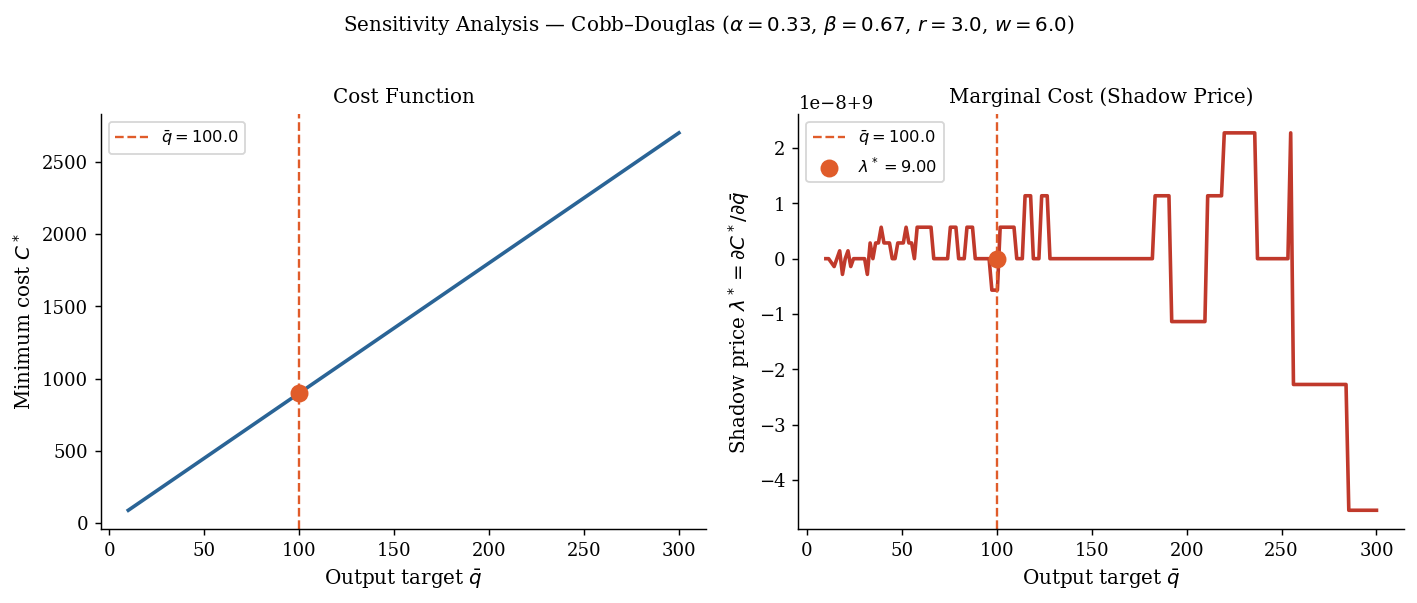

Figure saved as sensitivity_analysis.png


In [25]:
q_range = np.linspace(10, 300, 200)

# Vectorised closed-form expressions
def K_star_fn(q_val):
    return q_val * (ALPHA * W / (BETA * R)) ** BETA

def L_star_fn(q_val):
    return q_val * (BETA * R / (ALPHA * W)) ** ALPHA

def C_star_fn(q_val):
    return R * K_star_fn(q_val) + W * L_star_fn(q_val)

def lam_star_fn(q_val):
    """Shadow price = marginal cost = dC*/dq (numerical derivative)."""
    dq = 1e-5
    return (C_star_fn(q_val + dq) - C_star_fn(q_val - dq)) / (2 * dq)

C_vals   = C_star_fn(q_range)
lam_vals = lam_star_fn(q_range)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: minimum cost curve
axes[0].plot(q_range, C_vals, color='#2a6496', lw=2)
axes[0].axvline(Q_BAR, color='#e05c2a', ls='--', lw=1.3, label=f'$\\bar{{q}}={Q_BAR}$')
axes[0].scatter(Q_BAR, C_opt, color='#e05c2a', s=80, zorder=5)
axes[0].set_xlabel('Output target $\\bar{q}$', fontsize=11)
axes[0].set_ylabel('Minimum cost $C^*$', fontsize=11)
axes[0].set_title('Cost Function', fontsize=11)
axes[0].legend(fontsize=9)

# Right: shadow price (marginal cost)
axes[1].plot(q_range, lam_vals, color='#c0392b', lw=2)
axes[1].axvline(Q_BAR, color='#e05c2a', ls='--', lw=1.3, label=f'$\\bar{{q}}={Q_BAR}$')
axes[1].scatter(Q_BAR, lam_opt, color='#e05c2a', s=80, zorder=5,
                label=f'$\\lambda^*={lam_opt:.2f}$')
axes[1].set_xlabel('Output target $\\bar{q}$', fontsize=11)
axes[1].set_ylabel('Shadow price $\\lambda^* = \\partial C^*/\\partial \\bar{q}$', fontsize=11)
axes[1].set_title('Marginal Cost (Shadow Price)', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle(f'Sensitivity Analysis — Cobb–Douglas '
             f'($\\alpha={ALPHA:.2f}$, $\\beta={BETA:.2f}$, $r={R}$, $w={W}$)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as sensitivity_analysis.png")

---
## 6 · Results Summary

In [19]:
MRTS = (ALPHA / BETA) * (L_opt / K_opt)   # = F_K / F_L at optimum
price_ratio = R / W


print("Cost minimisation results\n")

print(f"The production function is F(K,L) = K^{ALPHA:.2f} L^{BETA:.2f}.")
print(f"Input prices are r = {R} for capital and w = {W} for labour.")
print(f"The firm wants to produce q̄ = {Q_BAR} units of output.\n")

print("Optimal input choices:")
print(f"Capital (K*) = {K_opt:.4f}")
print(f"Labour  (L*) = {L_opt:.4f}\n")

print(f"The minimum cost of producing this output is C* = {C_opt:.4f}.")
print(f"The shadow price (λ), which represents marginal cost, is {lam_opt:.4f}.\n")

print("Checking the optimality conditions:")
print(f"MRTS = {MRTS:.4f}")
print(f"Price ratio r/w = {price_ratio:.4f}")
print(f"MRTS equals r/w: {abs(MRTS - price_ratio) < 1e-8}")

print(f"\nProduction check: F(K*,L*) = {output_chk:.4f} (target output = {Q_BAR})")

Cost minimisation results

The production function is F(K,L) = K^0.33 L^0.67.
Input prices are r = 3.0 for capital and w = 6.0 for labour.
The firm wants to produce q̄ = 100.0 units of output.

Optimal input choices:
Capital (K*) = 100.0000
Labour  (L*) = 100.0000

The minimum cost of producing this output is C* = 900.0000.
The shadow price (λ), which represents marginal cost, is 9.0000.

Checking the optimality conditions:
MRTS = 0.5000
Price ratio r/w = 0.5000
MRTS equals r/w: True

Production check: F(K*,L*) = 100.0000 (target output = 100.0)
